In [1]:
!pip install torchinfo
!pip install --quiet torchview graphviz

In [2]:
import math
import os
import time
from datetime import timedelta
import random

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
from IPython.display import SVG, display

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from torchinfo import summary
from torchview import draw_graph

import torchvision.models as models

In [3]:
ROOT_DIR = "/kaggle/input/datasets/dreamer07/eyepacs"
BATCH_SIZE = 6
NUM_WORKERS = 4
RANDOM_STATE = 42

In [4]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

ROOT_DIR = "/kaggle/input/datasets/dreamer07/eyepacs"
CSV_PATH = "/kaggle/input/datasets/dreamer07/eyepacs/trainLabels.csv/trainLabels.csv"
IMAGE_DIR = "/kaggle/input/datasets/dreamer07/eyepacs/data/data"


# =========================
# EYE-PACS CSV LOADER
# =========================
def load_eyepacs_annotations():

    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"{CSV_PATH} not found")

    df = pd.read_csv(CSV_PATH)

    required_cols = ["image", "level"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    records = []
    missing_images = 0

    for _, row in df.iterrows():
        img_id = str(row["image"]).strip()
        label = int(row["level"])

        img_path = os.path.join(IMAGE_DIR, img_id + ".jpeg")  # ⚠️ eyepacs uses .jpeg

        if os.path.isfile(img_path):
            records.append((img_path, label))
        else:
            missing_images += 1

    df_records = pd.DataFrame(records, columns=["image_path", "label"])

    print("========== DATA SUMMARY ==========")
    print("Loaded images:", len(df_records))
    print("Missing images:", missing_images)
    print("Class distribution:")
    print(df_records["label"].value_counts().sort_index())
    print("==================================")

    return df_records


# LOAD DATA
df_all = load_eyepacs_annotations()

CLASSES = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

num_classes = len(CLASSES)

train_df, temp_df = train_test_split(
    df_all,
    test_size=0.30,
    stratify=df_all["label"],
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_STATE
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

========== DATA SUMMARY ==========
Loaded images: 35126
Missing images: 0
Class distribution:
label
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64

Split sizes:
Train: 24588
Val: 5269
Test: 5269


In [5]:
class EyePACSDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
IMG_SIZE = 224 

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [7]:
train_dataset = EyePACSDataset(train_df, transform=transform)
val_dataset = EyePACSDataset(val_df, transform=transform)
test_dataset = EyePACSDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

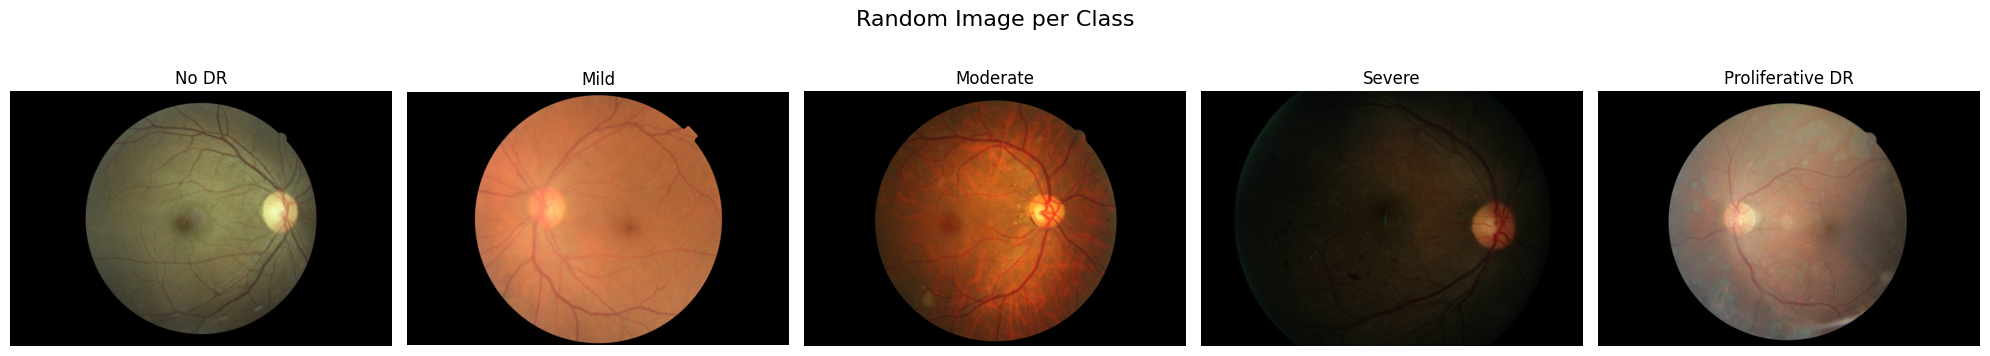

In [8]:
def show_random_images_per_class(df, classes, title="Random Image per Class"):
    num_classes = len(classes)
    fig, axs = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4))
    if num_classes == 1:
        axs = [axs]

    for i, cls in enumerate(range(num_classes)):
        class_df = df[df['label'] == cls]
        if len(class_df) == 0:
            axs[i].axis("off")
            axs[i].set_title(f"{classes[cls]}\n(No Images)")
            continue

        row = class_df.sample(n=1).iloc[0]
        image = Image.open(row['image_path']).convert('RGB')
        axs[i].imshow(image)
        axs[i].set_title(classes[cls], fontsize=12)
        axs[i].axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()
show_random_images_per_class(train_df, CLASSES)

In [9]:
class TinyViT(nn.Module):
    def __init__(self, in_channels=32, embed_dim=32):
        super().__init__()

        # Patch embedding (7x7)
        self.patch_embed = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=7,
            stride=7
        )

        # depth = 2 
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            dim_feedforward=32,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2   
        )

    def forward(self, x):
        x = self.patch_embed(x)   # (B,32,H/7,W/7)

        B, C, H, W = x.shape

        x = x.view(B, C, H * W).permute(0, 2, 1)  # (B,N,C)

        x = self.transformer(x)

        x = x.mean(dim=1)

        return x

In [10]:
class SAM_ViT_Branch(nn.Module):
    def __init__(self):
        super().__init__()

        # 3x3 → 1x1 conv
        self.conv = nn.Conv2d(
            224, 64,
            kernel_size=1,
            stride=1,
            padding=0
        )
        self.bn1 = nn.BatchNorm2d(64)

        self.dilated = nn.Conv2d(
            64, 32,
            kernel_size=3,
            stride=1,
            dilation=2,
            padding=0
        )
        self.bn2 = nn.BatchNorm2d(32)

        self.act = nn.GELU()

        self.vit = TinyViT(in_channels=32)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='bilinear')  # (B,112,28,28)

        avg = F.avg_pool2d(x, kernel_size=3, stride=1, padding=0)
        max_ = F.max_pool2d(x, kernel_size=3, stride=1, padding=0)

        x = torch.cat([avg, max_], dim=1)   # (B,224,26,26)

        # Now output stays (26,26) → SAME as before
        x = self.conv(x)   
        x = self.bn1(x)

        x = self.dilated(x)   # → (B,32,22,22)
        x = self.bn2(x)

        x = self.act(x)

        vit_feat = self.vit(x)

        return vit_feat

In [11]:
class EfficientNet_SAM_ViT(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        self.features = self.backbone.features

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        # SAM + ViT branch
        self.sam_vit = SAM_ViT_Branch()

        # 1280 + 32 
        self.classifier = nn.Linear(1280 + 32, num_classes)

    def forward(self, x):

        spatial_feat = None

        # ===== Backbone =====
        for i, layer in enumerate(self.features):
            x = layer(x)

            if i == 5:
                spatial_feat = x   # (B,112,14,14)

        # ===== Global Branch =====
        global_feat = self.global_pool(x)
        global_feat = torch.flatten(global_feat, 1)  # (B,1280)

        # ===== SAM + ViT Branch =====
        branch_feat = self.sam_vit(spatial_feat)     # (B,32)

        # ===== Fusion =====
        fused = torch.cat([global_feat, branch_feat], dim=1)  # (B,1312)

        # ===== Output =====
        out = self.classifier(fused)

        return out

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNet_SAM_ViT(num_classes).to(device)
model.to(device)
summary(model, input_size=(1, 3, 224, 224))

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 190MB/s]


Layer (type:depth-idx)                                       Output Shape              Param #
EfficientNet_SAM_ViT                                         [1, 5]                    1,281,000
├─Sequential: 1-1                                            --                        --
│    └─Conv2dNormActivation: 2-1                             [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                                      [1, 32, 112, 112]         864
│    │    └─BatchNorm2d: 3-2                                 [1, 32, 112, 112]         64
│    │    └─SiLU: 3-3                                        [1, 32, 112, 112]         --
│    └─Sequential: 2-2                                       [1, 16, 112, 112]         --
│    │    └─MBConv: 3-4                                      [1, 16, 112, 112]         1,448
│    └─Sequential: 2-3                                       [1, 24, 56, 56]           --
│    │    └─MBConv: 3-5                                      [1, 24, 56, 56]        

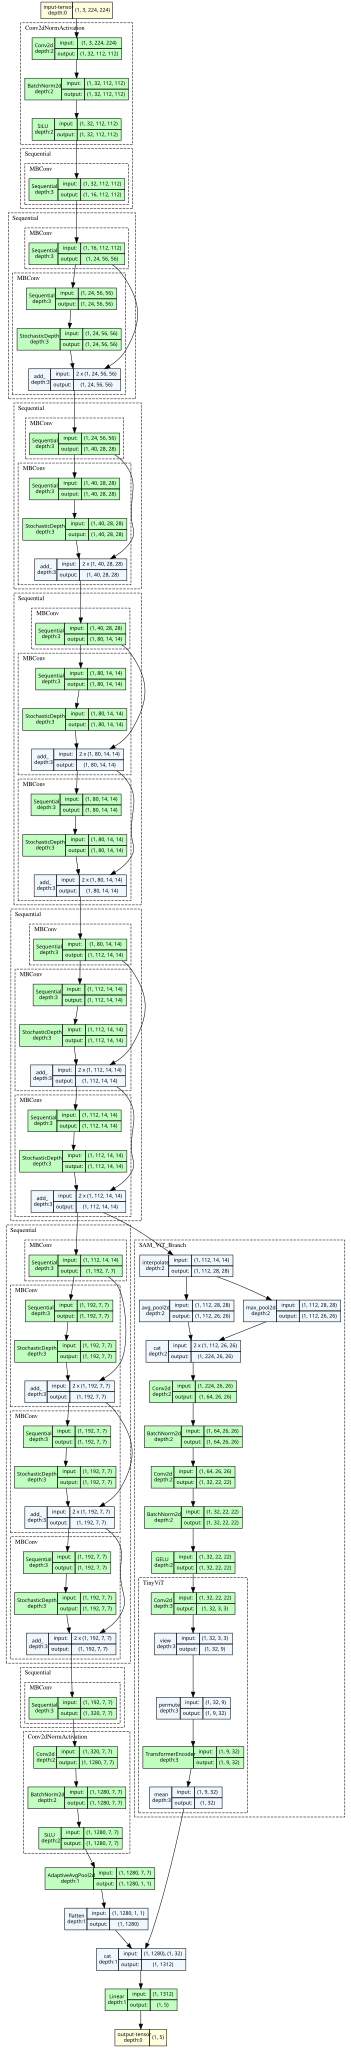

In [13]:
from torchview import draw_graph
from IPython.display import SVG, display

dummy_input = torch.randn(1, 3, 224, 224).to(device)

model_graph = draw_graph(
    model,
    input_data=dummy_input,
    expand_nested=True
)

svg = model_graph.visual_graph.pipe(format='svg')

display(SVG(svg))

with open("/kaggle/working/model_graph.svg", "wb") as f:
    f.write(svg)

In [14]:
def custom_metrics(y_pred, y_true, loss):
    y_pred_classes = torch.argmax(y_pred, dim=1)

    y_true_numpy = y_true.cpu().numpy()
    y_pred_classes_numpy = y_pred_classes.cpu().numpy()

    accuracy = accuracy_score(y_true_numpy, y_pred_classes_numpy)

    precision = precision_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    recall = recall_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    f1 = f1_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    num_classes = y_pred.shape[1]
    auc_scores = []

    for class_idx in range(num_classes):
        class_y_true = (y_true_numpy == class_idx).astype(np.float32)
        class_y_pred = y_pred[:, class_idx].cpu().numpy()

        if np.unique(class_y_true).size < 2:
            continue

        try:
            auc_score = roc_auc_score(class_y_true, class_y_pred)
            auc_scores.append(auc_score)
        except ValueError:
            continue

    auc_avg = np.mean(auc_scores) if auc_scores else 0.0

    metrics = {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc": auc_avg,
    }

    return metrics

In [15]:
# Hyperparameters
num_epochs = 7
initial_lr = 0.0005

# Criterion, optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=initial_lr)

# Plateau LR scheduler (fixed — no verbose arg)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.75,
    patience=5
)

In [16]:
import torch
import numpy as np
from tqdm import tqdm

metric_names = ["loss", "accuracy", "precision", "recall", "f1_score", "auc"]

train_metrics_history = {metric: [] for metric in metric_names}
val_metrics_history = {metric: [] for metric in metric_names}

best_val_loss = float("inf")
epochs_no_improve = 0

save_epochs = [7, 15]   # checkpoints to save

# ===== TRAINING LOOP =====
for epoch in range(num_epochs):

    print(f"\n🚀 Epoch [{epoch+1}/{num_epochs}]")

    # ===== TRAIN =====
    model.train()
    total_train_loss = 0.0
    all_train_predictions = []
    all_train_targets = []

    for data, targets in tqdm(train_loader, desc=f"Training Epoch [{epoch+1}/{num_epochs}]"):
        data = data.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        all_train_predictions.extend(outputs.detach().cpu().numpy())
        all_train_targets.extend(targets.detach().cpu().numpy())

    avg_train_loss = total_train_loss / len(train_loader)

    train_metrics = custom_metrics(
        torch.tensor(np.array(all_train_predictions)),
        torch.tensor(np.array(all_train_targets)),
        avg_train_loss
    )

    print("📊 Train Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in train_metrics.items()]))

    for metric in metric_names:
        train_metrics_history[metric].append(train_metrics[metric])


    # ===== VALIDATION =====
    model.eval()
    total_val_loss = 0.0
    all_val_predictions = []
    all_val_targets = []

    with torch.no_grad():
        for data, targets in tqdm(val_loader, desc="Validating Model"):
            data = data.to(device)
            targets = targets.to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)

            total_val_loss += loss.item()
            all_val_predictions.extend(outputs.detach().cpu().numpy())
            all_val_targets.extend(targets.detach().cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)

    val_metrics = custom_metrics(
        torch.tensor(np.array(all_val_predictions)),
        torch.tensor(np.array(all_val_targets)),
        avg_val_loss
    )

    print("📊 Val Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in val_metrics.items()]))

    for metric in metric_names:
        val_metrics_history[metric].append(val_metrics[metric])


    # ===== Save BEST model =====
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

        torch.save(model.state_dict(),
                   "/kaggle/working/best_model_weights.pth")

        torch.save(model,
                   "/kaggle/working/best_model_full.pth")

        print("✅ Best model saved (lowest val loss)")


    # ===== Save specific epoch checkpoints =====
    if (epoch + 1) in save_epochs:

        torch.save(model.state_dict(),
                   f"/kaggle/working/model_epoch_{epoch+1}_weights.pth")

        torch.save(model,
                   f"/kaggle/working/model_epoch_{epoch+1}_full.pth")

        print(f"📌 Model saved at Epoch {epoch+1}")


    # ===== Scheduler =====
    scheduler.step(avg_val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"📉 LR after epoch {epoch+1}: {current_lr:.6f}")


🚀 Epoch [1/7]


Training Epoch [1/7]: 100%|██████████| 4098/4098 [20:33<00:00,  3.32it/s]


📊 Train Metrics - loss: 0.7468, accuracy: 0.7529, precision: 0.6596, recall: 0.7529, f1_score: 0.6873, auc: 0.7491


Validating Model: 100%|██████████| 879/879 [03:56<00:00,  3.72it/s]


📊 Val Metrics - loss: 0.6910, accuracy: 0.7800, precision: 0.6951, recall: 0.7800, f1_score: 0.7297, auc: 0.7939
✅ Best model saved (lowest val loss)
📉 LR after epoch 1: 0.000500

🚀 Epoch [2/7]


...

📊 Val Metrics - loss: 0.6216, accuracy: 0.8003, precision: 0.7404, recall: 0.8003, f1_score: 0.7535, auc: 0.8162
✅ Best model saved (lowest val loss)
📉 LR after epoch 6: 0.000500

🚀 Epoch [7/7]


Training Epoch [7/7]: 100%|██████████| 4098/4098 [16:27<00:00,  4.15it/s]


📊 Train Metrics - loss: 0.4959, accuracy: 0.8347, precision: 0.7950, recall: 0.8347, f1_score: 0.7983, auc: 0.8563


Validating Model: 100%|██████████| 879/879 [03:24<00:00,  4.30it/s]


📊 Val Metrics - loss: 0.6440, accuracy: 0.7994, precision: 0.7293, recall: 0.7994, f1_score: 0.7546, auc: 0.8263
📌 Model saved at Epoch 7
📉 LR after epoch 7: 0.000500


In [17]:
state_dict = torch.load("/kaggle/working/model_epoch_7_weights.pth")

model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print("✅ Best model loaded successfully")

✅ Best model loaded successfully


In [18]:
#model.eval()
total_test_loss = 0.0
all_test_predictions = []
all_test_targets = []

with torch.no_grad():
    for batch_idx, (data, targets) in enumerate(tqdm(test_loader, desc="Testing Model")):
        data = data.to(device)
        targets = targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets)
        total_test_loss += loss.item()

        all_test_predictions.extend(outputs.detach().cpu().numpy())
        all_test_targets.extend(targets.detach().cpu().numpy())

all_test_predictions = np.array(all_test_predictions)
all_test_targets = np.array(all_test_targets)

average_test_loss = total_test_loss / len(test_loader)

test_metrics = custom_metrics(
    torch.tensor(all_test_predictions),
    torch.tensor(all_test_targets),
    average_test_loss
)

testing_metrics_line = "Test Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in test_metrics.items()])
print(testing_metrics_line)

Testing Model: 100%|██████████| 879/879 [03:46<00:00,  3.89it/s]

Test Metrics - loss: 0.6483, accuracy: 0.8026, precision: 0.7318, recall: 0.8026, f1_score: 0.7566, auc: 0.8210


In [19]:
true_labels = np.array(all_test_targets)
predicted_labels = np.argmax(np.array(all_test_predictions), axis=1)

true_labels = true_labels.astype(int)
predicted_labels = predicted_labels.astype(int)

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASSES,
    digits=4
)

accuracy = accuracy_score(true_labels, predicted_labels)
num_errors = np.sum(true_labels != predicted_labels)

print(report)
print(f'There were {num_errors} errors in {len(predicted_labels)} tests for an accuracy of {accuracy * 100:6.2f}%')

                  precision    recall  f1-score   support

           No DR     0.8265    0.9842    0.8985      3872
            Mild     0.0000    0.0000    0.0000       366
        Moderate     0.6591    0.4018    0.4992       794
          Severe     0.5278    0.2901    0.3744       131
Proliferative DR     0.5980    0.5755    0.5865       106

        accuracy                         0.8026      5269
       macro avg     0.5223    0.4503    0.4717      5269
    weighted avg     0.7318    0.8026    0.7566      5269

There were 1040 errors in 5269 tests for an accuracy of  80.26%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
